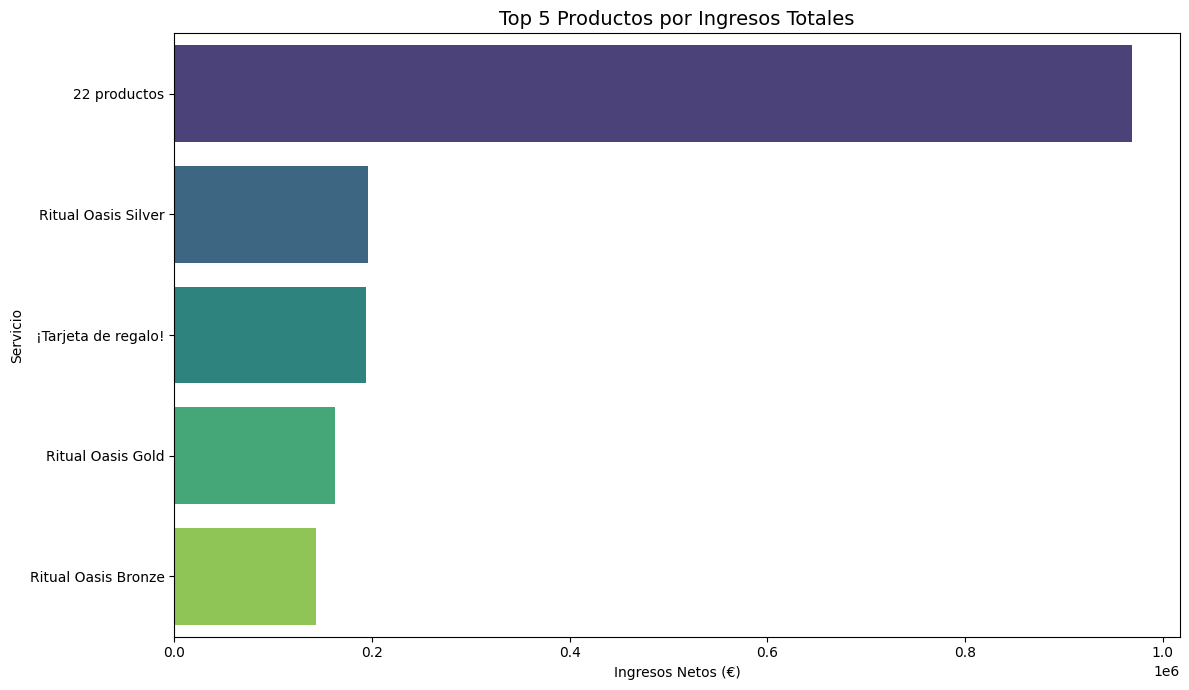

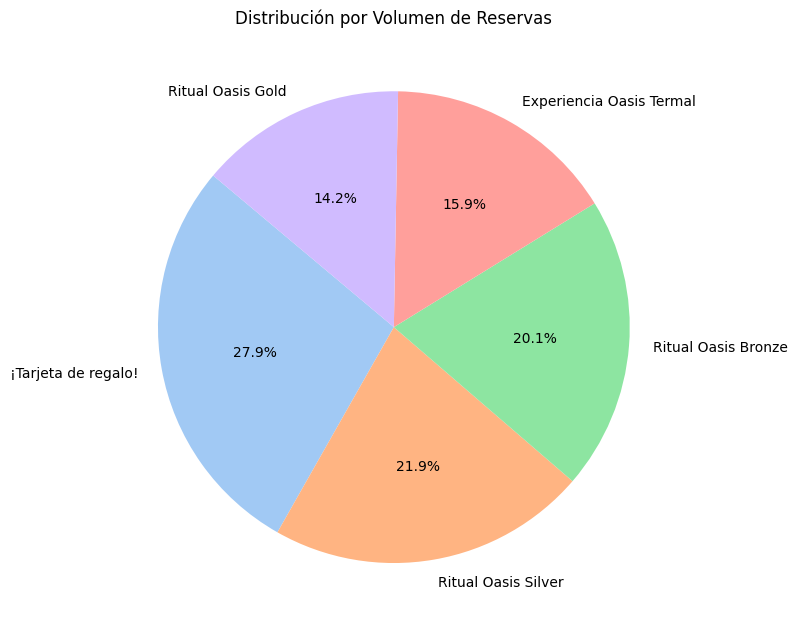

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

#Carga de datos
df_ventas = pd.read_csv('../data/informe_ventas.csv', skiprows=1)

#Función de limpieza de nombres
def limpiar_nombres_columnas(df):
    df.columns = (df.columns.str.strip().str.lower()
                  .str.replace(' ', '_').str.replace('¿', '').str.replace('?', '')
                  .str.replace('.', '').str.replace('á', 'a').str.replace('é', 'e')
                  .str.replace('í', 'i').str.replace('ó', 'o').str.replace('ú', 'u'))
    return df

df_ventas = limpiar_nombres_columnas(df_ventas)

#LIMPIEZA DE MONEDA
def limpiar_moneda(valor):
    if isinstance(valor, str):
        # Quitamos €, puntos de miles y cambiamos coma por punto decimal
        valor = valor.replace('€', '').replace('.', '').replace(',', '.').strip()
    return pd.to_numeric(valor, errors='coerce')

df_ventas['neto'] = df_ventas['neto'].apply(limpiar_moneda)

#Agrupamos por producto
productos_top = df_ventas.groupby('producto')['neto'].agg(['sum', 'count']).sort_values(by='sum', ascending=False)

#GRÁFICO 1: INGRESOS
plt.figure(figsize=(12, 7))
sns.barplot(
    x=productos_top['sum'].head(5), 
    y=productos_top.index[:5], 
    palette='viridis', 
    hue=productos_top.index[:5], 
    legend=False
)
plt.title('Top 5 Productos por Ingresos Totales', fontsize=14)
plt.xlabel('Ingresos Netos (€)')
plt.ylabel('Servicio')
plt.tight_layout()

#Guardado y cierre
plt.savefig('../img/03_producto_estrella_ingresos.png', dpi=300)
plt.show()
plt.close() 

#GRÁFICO 2: VOLUMEN
plt.figure(figsize=(8, 8))
df_ventas['producto'].value_counts().head(5).plot(
    kind='pie', 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=sns.color_palette('pastel')
)
plt.title('Distribución por Volumen de Reservas')
plt.ylabel('')
plt.tight_layout()

#Guardado y cierre
plt.savefig('../img/03_producto_volumen.png', dpi=300)
plt.show()
plt.close()

In [2]:
#ANONIMIZACIÓN
# email -> cliente_id (entero) | CP -> cp_provincia (2 dígitos)
import sys
sys.path.insert(0, '../utils')
from funciones import anonimizar

df_ventas = anonimizar(df_ventas)
print("Anonimización aplicada. Columnas df_ventas:", df_ventas.columns.tolist())

Anonimización aplicada. Columnas df_ventas: ['producto', 'mes_del_pago', 'creado_el', 'tipo_de_pago', 'cargo_de_gestion', 'neto', 'id_de_reserva', 'reprogramacion', 'pais_del_telefono', 'cliente_id', 'cp_area']
